# Project 4: Sentiment Analysis
**Oasis Infobyte - Level 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Build Dataset

In [2]:
positive = [
    'This product is absolutely amazing and fantastic',
    'Great quality and fast delivery highly recommend',
    'Excellent service wonderful experience loved it',
    'Best purchase ever outstanding quality',
    'Very happy with this product works perfectly',
    'Superb quality great value for money',
    'Love this product it exceeded my expectations',
    'Awesome quality will definitely buy again',
    'Fantastic buy would recommend to everyone',
    'Really impressed with the quality and performance'
]*15

negative = [
    'Terrible product waste of money',
    'Very disappointed poor quality broken on arrival',
    'Worst purchase ever do not buy this',
    'Bad quality product stopped working in one week',
    'Awful experience never buying from here again',
    'Horrible product completely useless',
    'Very poor quality not worth the price',
    'Extremely disappointed with this purchase',
    'Waste of money bad quality cheap material',
    'Absolutely terrible would not recommend'
]*15

neutral = [
    'Product is okay nothing special',
    'Average quality meets basic requirements',
    'It is fine does the job as expected',
    'Neither good nor bad just okay',
    'Acceptable product for the price',
    'Mediocre quality could be better',
    'Decent product not much to say',
    'Average experience delivery was on time',
    'Product works as described nothing more',
    'Okay product standard quality'
]*10

texts = positive + negative + neutral
labels = ['Positive']*150 + ['Negative']*150 + ['Neutral']*100
df = pd.DataFrame({'Review':texts, 'Sentiment':labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print('Dataset shape:', df.shape)
df['Sentiment'].value_counts()

Dataset shape: (400, 2)


,count
Sentiment,
Negative,150
Positive,150
Neutral,100


## Step 2: Preprocess & Visualize

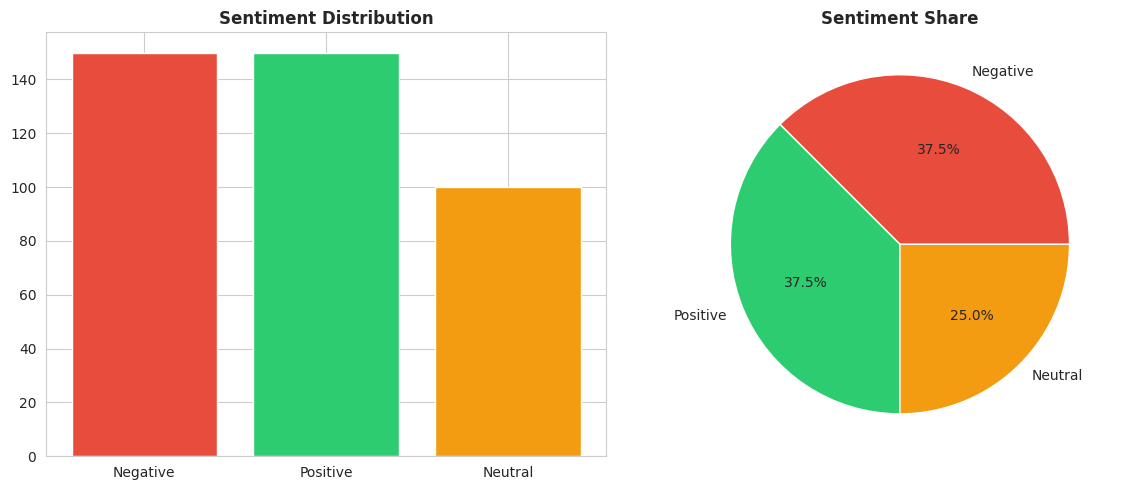

In [3]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df['Clean'] = df['Review'].apply(preprocess)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
colors = {'Positive':'#2ECC71','Negative':'#E74C3C','Neutral':'#F39C12'}
counts = df['Sentiment'].value_counts()
bar_colors = [colors[s] for s in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors)
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=bar_colors)
axes[1].set_title('Sentiment Share', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 3: TF-IDF & Train Models

In [4]:
X = df['Clean']; y = df['Sentiment']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_tr = tfidf.fit_transform(X_train)
X_te = tfidf.transform(X_test)

models = {'Naive Bayes': MultinomialNB(alpha=0.5), 'SVM': LinearSVC(random_state=42, max_iter=2000)}
results = {}
for name, model in models.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name] = {'preds': preds, 'acc': acc}
    print(f'{name}: Accuracy = {acc:.4f}')

best = max(results, key=lambda x: results[x]['acc'])
print(f'Best Model: {best}')

Naive Bayes: Accuracy = 1.0000
SVM: Accuracy = 1.0000
Best Model: Naive Bayes


## Step 4: Evaluate & Test

=== Naive Bayes Report ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        38
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



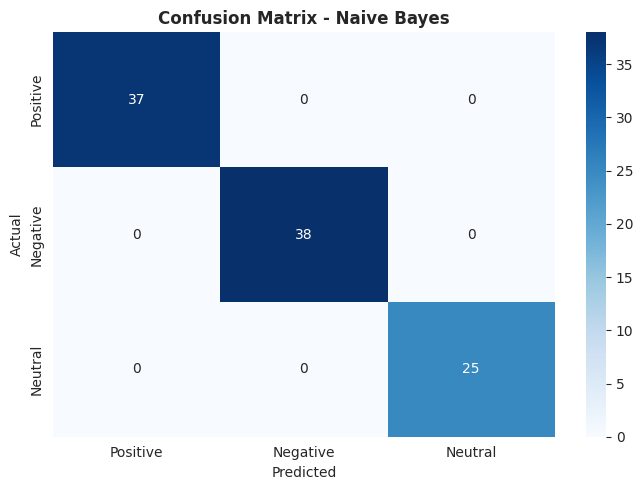

"This product is amazing and great" -> Positive
"Terrible quality very disappointed" -> Negative
"It is okay nothing special" -> Neutral


In [5]:
best_preds = results[best]['preds']
print(f'=== {best} Report ===')
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds, labels=['Positive','Negative','Neutral'])
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive','Negative','Neutral'],
            yticklabels=['Positive','Negative','Neutral'])
plt.title(f'Confusion Matrix - {best}', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# Test custom inputs
best_model = models[best]
for review in ['This product is amazing and great','Terrible quality very disappointed','It is okay nothing special']:
    vec = tfidf.transform([preprocess(review)])
    pred = best_model.predict(vec)[0]
    print(f'"{review}" -> {pred}')